# PySILLS tutorial: fluid inclusion analysis

### Focus: second-internal-standard

This notebook demonstrates a minimal workflow for quantifying LA-ICP-MS
fluid inclusion measurements using the *matrix-only tracer method*.

Workflow:

1. Import LA-ICP-MS data
2. Inspect the raw signal
3. Prepare the dataset
4. Calculate sensitivities
5. Quantify element concentrations

#### Background and theoretical framework

#### Packages and modules

In [3]:
# Packages
%matplotlib inline
import numpy as np
import pandas as pd
import ipywidgets as widgets
import matplotlib.pyplot as plt

pd.options.display.float_format = "{:.5f}".format

from pathlib import Path
from IPython.display import display, clear_output
from ipywidgets import interact, fixed, interactive

# Modules
from pysills.core.sensitivities.datareduction_sensitivities import DataReductionSensitivities as DRS
from pysills.core.intensities.datareduction_intensities import DataReductionIntensities as DRI
from pysills.core.concentrations.srm_concentrations import StandardReferenceMaterial as SRM
from pysills.core.sensitivities.datareduction_sensitivities import build_isotope_to_element_mapping
from pysills.core.concentrations.smpl_concentrations import SampleAnalysis as SA
from pysills.core.io.icpms_reader import ICPMSReader


#### Helper functions

In [5]:
def plot_file(df, intervals_bg=None, intervals_mat=None, intervals_incl=None, xlimits=None, focus="All"):
    list_isotopes = list(df.keys())[1:]
    x_data = df["time_s"]
    if xlimits is None:
        xmin = x_data.min()
        xmax = x_data.max()
    else:
        t_0 = xlimits[0]
        t_1 = xlimits[1]
        idx_0 = dri.find_index_for_time(df_ready=df, time_value=t_0)
        idx_1 = dri.find_index_for_time(df_ready=df, time_value=t_1)
        xmin = x_data.iloc[idx_0]
        xmax = x_data.iloc[idx_1]

    ymin = 100
    ymax = 10**9
    
    fig, ax = plt.subplots(figsize=(11, 6))
    
    if focus == "All":
        list_isotopes = list(df.keys())[1:]
        for isotope in list_isotopes:
            y_data = df[isotope]
            ax.plot(x_data, y_data, label=isotope)
    else:
        y_data = df[focus]
        ax.plot(x_data, y_data, label=focus)

    if intervals_bg is not None:
        for key, interval in intervals_bg.items():
            t_0 = interval[0]
            t_1 = interval[1]
            idx_0 = dri.find_index_for_time(df_ready=df, time_value=t_0)
            idx_1 = dri.find_index_for_time(df_ready=df, time_value=t_1)
            ax.axvspan(x_data.iloc[idx_0], x_data.iloc[idx_1], color="tan", alpha=0.5, label=key)

    if intervals_mat is not None:
        for key, interval in intervals_mat.items():
            t_0 = interval[0]
            t_1 = interval[1]
            idx_0 = dri.find_index_for_time(df_ready=df, time_value=t_0)
            idx_1 = dri.find_index_for_time(df_ready=df, time_value=t_1)
            ax.axvspan(x_data.iloc[idx_0], x_data.iloc[idx_1], color="slategrey", alpha=0.5, label=key)

    if intervals_incl is not None:
        for key, interval in intervals_incl.items():
            t_0 = interval[0]
            t_1 = interval[1]
            idx_0 = dri.find_index_for_time(df_ready=df, time_value=t_0)
            idx_1 = dri.find_index_for_time(df_ready=df, time_value=t_1)
            ax.axvspan(x_data.iloc[idx_0], x_data.iloc[idx_1], color="salmon", alpha=0.5, label=key)
    
    ax.set_yscale("log")

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_xticks(np.linspace(xmin, xmax, 10))

    ax.grid(linestyle="dashed")

    ax.set_xlabel("Time t (s)")
    ax.set_ylabel("Intensity I (cps)")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, ncols=2)

    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()
    

#### Definition of internal standard (for inclusion and matrix) and matrix-only tracer

In [7]:
ref_element_matrix = "Si"
ref_isotope_matrix = "Si29"
ref_element_2 = "As"
ref_isotope_2 = "As75"
ref_element = "Na"
ref_isotope = "Na23"

reference_concentration_mat = 467436.7125
concentration_incl_is2 = {"demo_fi05.csv": 2137.07749, "demo_fi06.csv": 1800.24031}
concentration_incl_is = {"demo_fi05.csv": 19415.2373, "demo_fi06.csv": 19344.7604}


#### Data import (Standard Reference Material (SRM))

In [9]:
srm = SRM(sep=";")

srm_filenames = ["NIST_610_GeoReM.csv", "Scapolite_17.csv"]
srm_dir = Path("../src/pysills/legacy/lib/srm")
df_srm_i_ratios = {}
df_srm_i = {}

for fname in srm_filenames:
    file_path = srm_dir/fname
    df_srm = srm.read_input_data(file_path)
    i_ratios_srm = srm.compute_concentration_ratios(df_srm, reference_element=ref_element)
    df_srm_i[fname] = df_srm
    df_srm_i_ratios[fname] = i_ratios_srm


#### Data import (from LA-ICP-MS measurements)

* If *zero_time* in *DRI()* is set *False*, *PySILLS* will not correct the measured time values with the first time starting at 0.0

In [11]:
demo_dir = Path("../src/pysills/legacy/lib/demo_files")

dri = DRI(zero_time=False)
reader = ICPMSReader()

files_srm_setup = {
    "demo_fi01.csv": {"BG": [1.0, 40.2], "MAT": [46.9, 91.7], "SRM": "NIST_610_GeoReM.csv"},
    "demo_fi02.csv": {"BG": [1.0, 40.2], "MAT": [46.9, 91.0], "SRM": "NIST_610_GeoReM.csv"},
    "demo_fi03.csv": {"BG": [1.0, 39.9], "MAT": [46.4, 91.5], "SRM": "Scapolite_17.csv"},
    "demo_fi04.csv": {"BG": [1.0, 40.8], "MAT": [47.5, 91.4], "SRM": "Scapolite_17.csv"},
    "demo_fi10.csv": {"BG": [1.0, 40.8], "MAT": [47.5, 91.7], "SRM": "NIST_610_GeoReM.csv"},
    "demo_fi11.csv": {"BG": [1.0, 40.2], "MAT": [46.9, 90.7], "SRM": "NIST_610_GeoReM.csv"},
    "demo_fi12.csv": {"BG": [1.8, 40.5], "MAT": [49.4, 89.8], "SRM": "Scapolite_17.csv"},
    "demo_fi13.csv": {"BG": [1.0, 39.9], "MAT": [46.4, 90.7], "SRM": "Scapolite_17.csv"}}

files_smpl_setup = {
    "demo_fi05.csv": {"BG": [235.9, 296.8], "MAT1": [106.7, 120.4], "MAT2": [134.5, 140.1], "INCL": [121.8, 133.8]},
    "demo_fi06.csv": {"BG": [4.5, 41.9], "MAT1": [85.6, 94.8], "MAT2": [166.7, 176.2], "INCL": [106.4, 156.0]}}

filepaths_list = []
for filename in files_srm_setup.keys():
    file_path = demo_dir/filename
    filepaths_list.append(file_path)
for filename in files_smpl_setup.keys():
    file_path = demo_dir/filename
    filepaths_list.append(file_path)
runs = reader.read_many(filepaths_list)
time_deltas = {}
for run in runs:
    t_rel = run["t_rel"]
    filename = run["filename"]
    time_deltas[filename] = {"time_delta": t_rel}


#### Import standard data (from LA-ICP-MS experiments)

In [13]:
srm_sensitivities_nist610 = {}
srm_sensitivities_sca17 = {}
srm_intensities = {}

#### demo_fi01

['Li7', 'B11', 'Na23', 'Mg24', 'Si29', 'S32', 'Cl35', 'K39', 'Ca44', 'Ti49', 'Mn55', 'Fe57', 'Cu63', 'Zn66', 'As75', 'Br81', 'Rb85', 'Sr88', 'Ag107', 'Sb121', 'Cs133', 'Ba137', 'W182', 'Au197', 'Pb208']


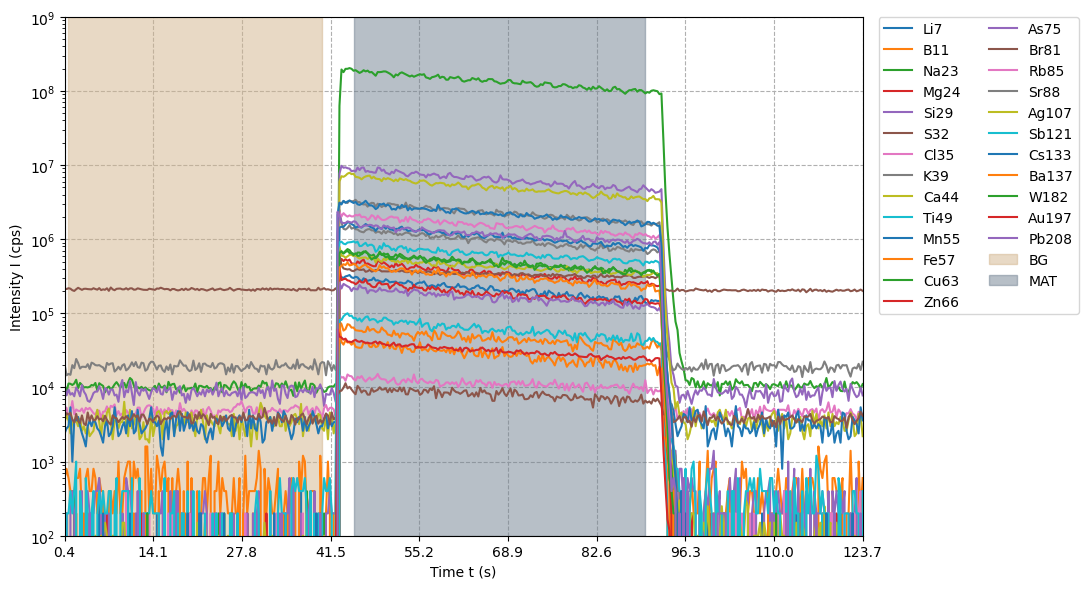

In [69]:
fname = "demo_fi01.csv"
file_path = demo_dir/fname
df = dri.read_input_data(file_path)
df_ready = dri.prepare_for_reduction(df)
list_isotopes = list(df_ready.keys())[1:]
print(list_isotopes)

if "BG" in files_srm_setup[fname]:
    intervals_bg = {"BG": files_srm_setup[fname]["BG"]}
else:
    intervals_bg = {"BG": [5, 40]}

if "MAT" in files_srm_setup[fname]:
    intervals_mat = {"MAT": [45, 90]}
else:
    intervals_mat = {"MAT": [45, 90]}

for key, interval in intervals_bg.items():
    if fname not in files_srm_setup:
        files_srm_setup[fname] = {}
    files_srm_setup[fname][key] = interval
    
for key, interval in intervals_mat.items():
    files_srm_setup[fname][key] = interval

plot_file(df=df_ready, intervals_bg=intervals_bg, intervals_mat=intervals_mat)


#### demo_fi02

['Li7', 'B11', 'Na23', 'Mg24', 'Si29', 'S32', 'Cl35', 'K39', 'Ca44', 'Ti49', 'Mn55', 'Fe57', 'Cu63', 'Zn66', 'As75', 'Br81', 'Rb85', 'Sr88', 'Ag107', 'Sb121', 'Cs133', 'Ba137', 'W182', 'Au197', 'Pb208']


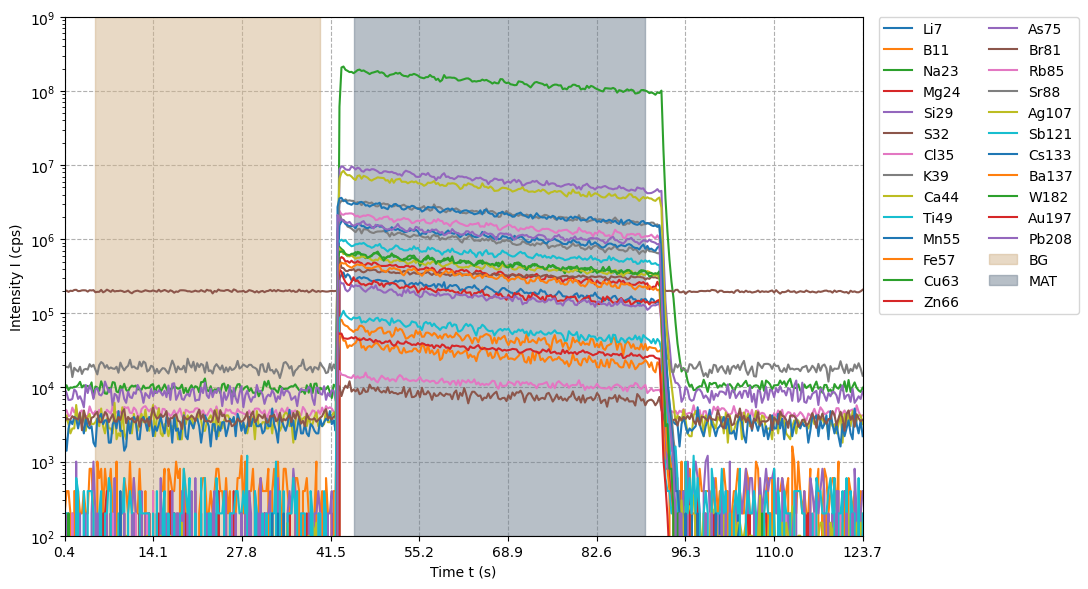

In [17]:
fname = "demo_fi02.csv"
file_path = demo_dir/fname
df = dri.read_input_data(file_path)
df_ready = dri.prepare_for_reduction(df)
list_isotopes = list(df_ready.keys())[1:]
print(list_isotopes)

if "BG" in files_srm_setup[fname]:
    intervals_bg = {"BG": files_srm_setup[fname]["BG"]}
else:
    intervals_bg = {"BG": [5, 40]}

if "MAT" in files_srm_setup[fname]:
    intervals_mat = {"MAT": [45, 90]}
else:
    intervals_mat = {"MAT": [45, 90]}

for key, interval in intervals_bg.items():
    if fname not in files_srm_setup:
        files_srm_setup[fname] = {}
    files_srm_setup[fname][key] = interval
    
for key, interval in intervals_mat.items():
    files_srm_setup[fname][key] = interval

plot_file(df=df_ready, intervals_bg=intervals_bg, intervals_mat=intervals_mat)


#### demo_fi03

['Li7', 'B11', 'Na23', 'Mg24', 'Si29', 'S32', 'Cl35', 'K39', 'Ca44', 'Ti49', 'Mn55', 'Fe57', 'Cu63', 'Zn66', 'As75', 'Br81', 'Rb85', 'Sr88', 'Ag107', 'Sb121', 'Cs133', 'Ba137', 'W182', 'Au197', 'Pb208']


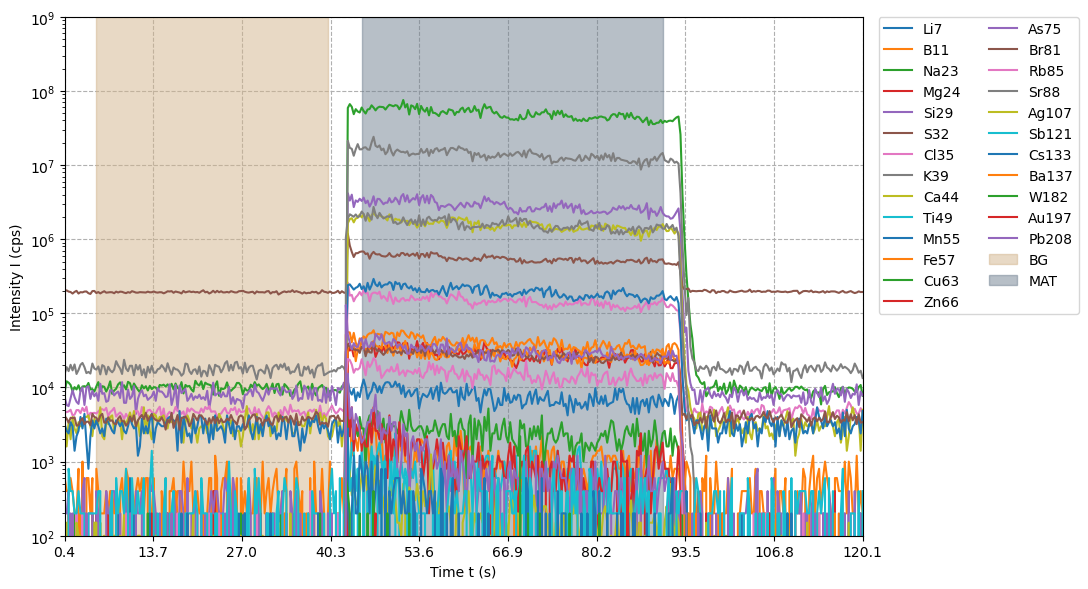

In [19]:
fname = "demo_fi03.csv"
file_path = demo_dir/fname
df = dri.read_input_data(file_path)
df_ready = dri.prepare_for_reduction(df)
list_isotopes = list(df_ready.keys())[1:]
print(list_isotopes)

if "BG" in files_srm_setup[fname]:
    intervals_bg = {"BG": files_srm_setup[fname]["BG"]}
else:
    intervals_bg = {"BG": [5, 40]}

if "MAT" in files_srm_setup[fname]:
    intervals_mat = {"MAT": [45, 90]}
else:
    intervals_mat = {"MAT": [45, 90]}

for key, interval in intervals_bg.items():
    if fname not in files_srm_setup:
        files_srm_setup[fname] = {}
    files_srm_setup[fname][key] = interval
    
for key, interval in intervals_mat.items():
    files_srm_setup[fname][key] = interval

plot_file(df=df_ready, intervals_bg=intervals_bg, intervals_mat=intervals_mat)


#### demo_fi04

['Li7', 'B11', 'Na23', 'Mg24', 'Si29', 'S32', 'Cl35', 'K39', 'Ca44', 'Ti49', 'Mn55', 'Fe57', 'Cu63', 'Zn66', 'As75', 'Br81', 'Rb85', 'Sr88', 'Ag107', 'Sb121', 'Cs133', 'Ba137', 'W182', 'Au197', 'Pb208']


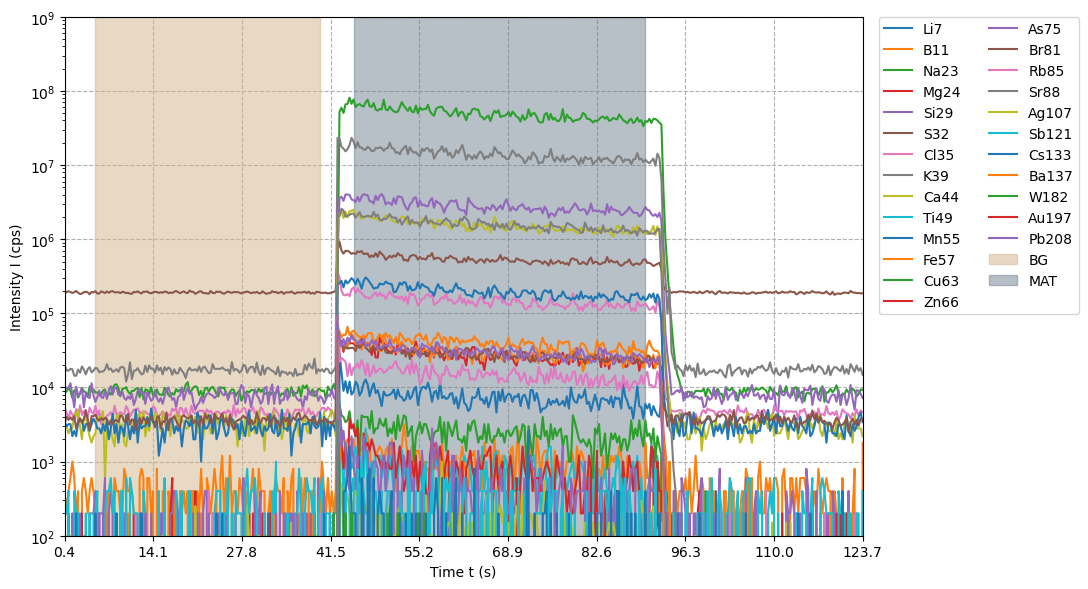

In [21]:
fname = "demo_fi04.csv"
file_path = demo_dir/fname
df = dri.read_input_data(file_path)
df_ready = dri.prepare_for_reduction(df)
list_isotopes = list(df_ready.keys())[1:]
print(list_isotopes)

if "BG" in files_srm_setup[fname]:
    intervals_bg = {"BG": files_srm_setup[fname]["BG"]}
else:
    intervals_bg = {"BG": [5, 40]}

if "MAT" in files_srm_setup[fname]:
    intervals_mat = {"MAT": [45, 90]}
else:
    intervals_mat = {"MAT": [45, 90]}

for key, interval in intervals_bg.items():
    if fname not in files_srm_setup:
        files_srm_setup[fname] = {}
    files_srm_setup[fname][key] = interval
    
for key, interval in intervals_mat.items():
    files_srm_setup[fname][key] = interval

plot_file(df=df_ready, intervals_bg=intervals_bg, intervals_mat=intervals_mat)


#### demo_fi10

['Li7', 'B11', 'Na23', 'Mg24', 'Si29', 'S32', 'Cl35', 'K39', 'Ca44', 'Ti49', 'Mn55', 'Fe57', 'Cu63', 'Zn66', 'As75', 'Br81', 'Rb85', 'Sr88', 'Ag107', 'Sb121', 'Cs133', 'Ba137', 'W182', 'Au197', 'Pb208']


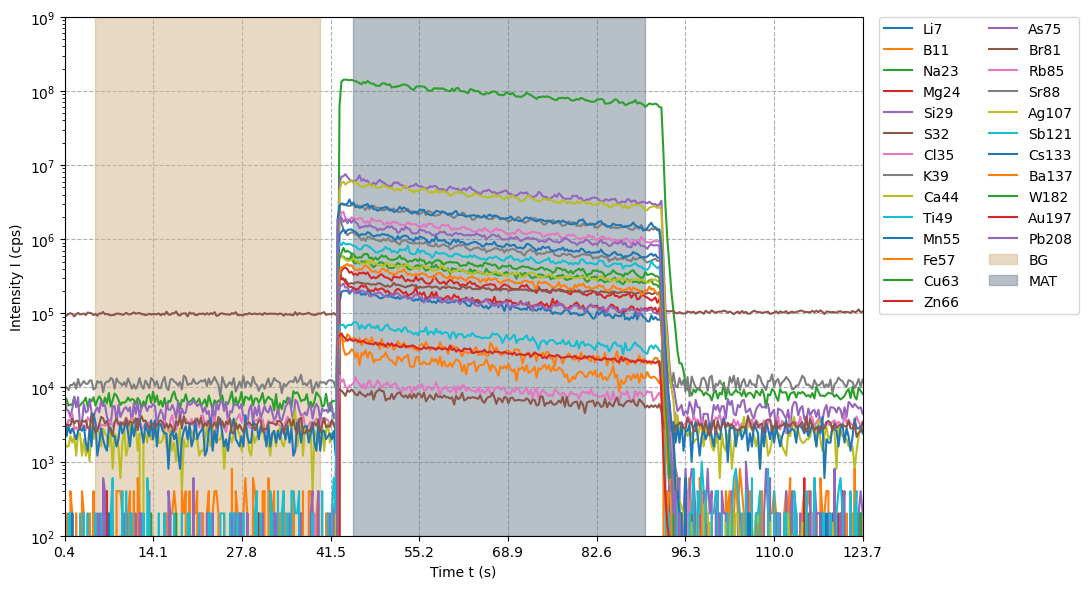

In [23]:
fname = "demo_fi10.csv"
file_path = demo_dir/fname
df = dri.read_input_data(file_path)
df_ready = dri.prepare_for_reduction(df)
list_isotopes = list(df_ready.keys())[1:]
print(list_isotopes)

if "BG" in files_srm_setup[fname]:
    intervals_bg = {"BG": files_srm_setup[fname]["BG"]}
else:
    intervals_bg = {"BG": [5, 40]}

if "MAT" in files_srm_setup[fname]:
    intervals_mat = {"MAT": [45, 90]}
else:
    intervals_mat = {"MAT": [45, 90]}

for key, interval in intervals_bg.items():
    if fname not in files_srm_setup:
        files_srm_setup[fname] = {}
    files_srm_setup[fname][key] = interval
    
for key, interval in intervals_mat.items():
    files_srm_setup[fname][key] = interval

plot_file(df=df_ready, intervals_bg=intervals_bg, intervals_mat=intervals_mat)


#### demo_fi11

['Li7', 'B11', 'Na23', 'Mg24', 'Si29', 'S32', 'Cl35', 'K39', 'Ca44', 'Ti49', 'Mn55', 'Fe57', 'Cu63', 'Zn66', 'As75', 'Br81', 'Rb85', 'Sr88', 'Ag107', 'Sb121', 'Cs133', 'Ba137', 'W182', 'Au197', 'Pb208']


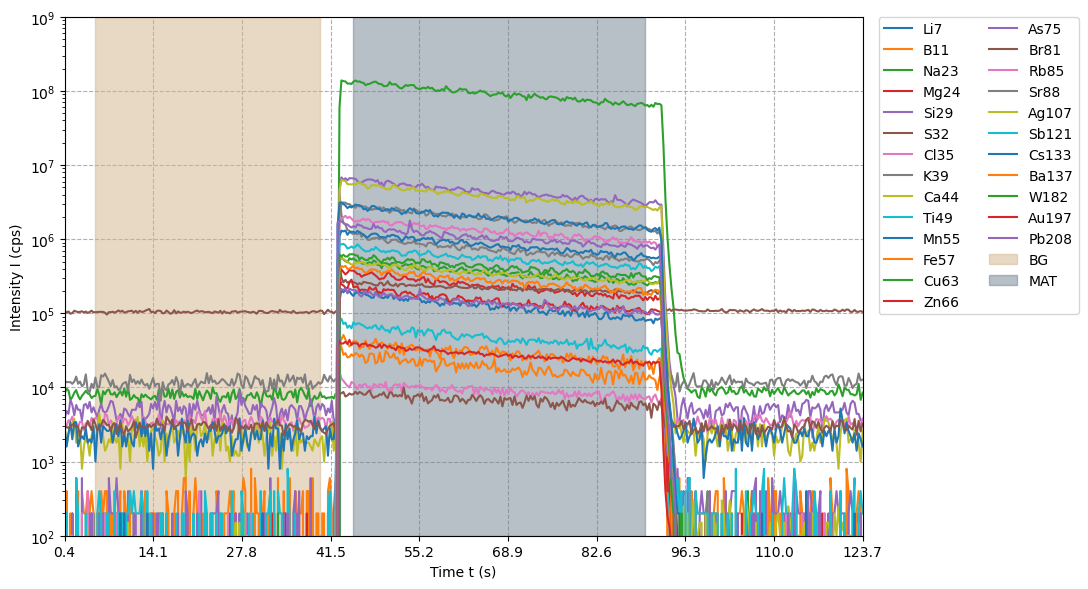

In [25]:
fname = "demo_fi11.csv"
file_path = demo_dir/fname
df = dri.read_input_data(file_path)
df_ready = dri.prepare_for_reduction(df)
list_isotopes = list(df_ready.keys())[1:]
print(list_isotopes)

if "BG" in files_srm_setup[fname]:
    intervals_bg = {"BG": files_srm_setup[fname]["BG"]}
else:
    intervals_bg = {"BG": [5, 40]}

if "MAT" in files_srm_setup[fname]:
    intervals_mat = {"MAT": [45, 90]}
else:
    intervals_mat = {"MAT": [45, 90]}

for key, interval in intervals_bg.items():
    if fname not in files_srm_setup:
        files_srm_setup[fname] = {}
    files_srm_setup[fname][key] = interval
    
for key, interval in intervals_mat.items():
    files_srm_setup[fname][key] = interval

plot_file(df=df_ready, intervals_bg=intervals_bg, intervals_mat=intervals_mat)


#### demo_fi12

['Li7', 'B11', 'Na23', 'Mg24', 'Si29', 'S32', 'Cl35', 'K39', 'Ca44', 'Ti49', 'Mn55', 'Fe57', 'Cu63', 'Zn66', 'As75', 'Br81', 'Rb85', 'Sr88', 'Ag107', 'Sb121', 'Cs133', 'Ba137', 'W182', 'Au197', 'Pb208']


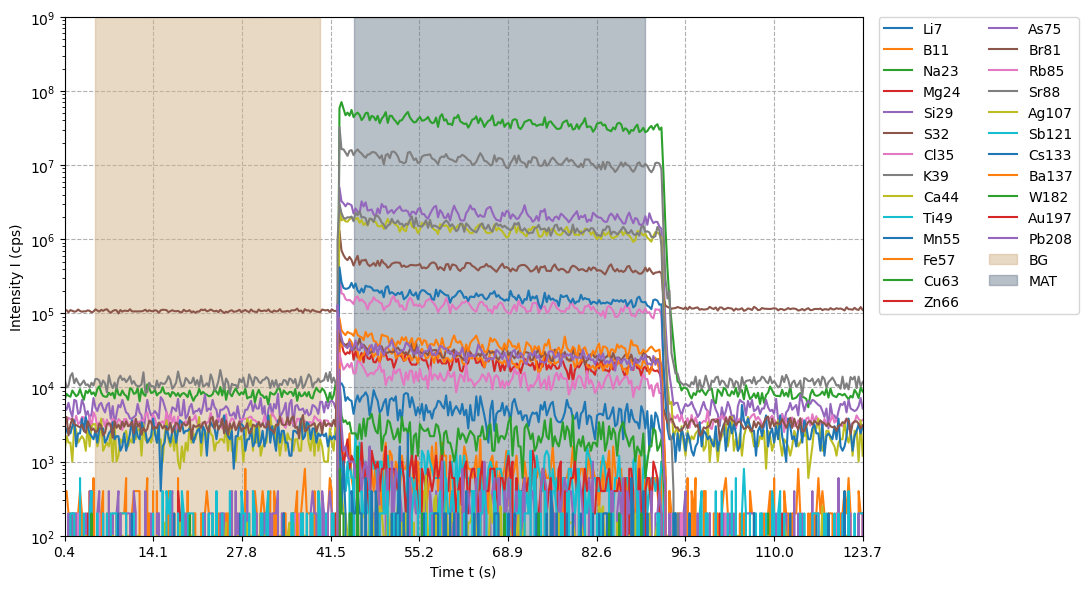

In [27]:
fname = "demo_fi12.csv"
file_path = demo_dir/fname
df = dri.read_input_data(file_path)
df_ready = dri.prepare_for_reduction(df)
list_isotopes = list(df_ready.keys())[1:]
print(list_isotopes)

if "BG" in files_srm_setup[fname]:
    intervals_bg = {"BG": files_srm_setup[fname]["BG"]}
else:
    intervals_bg = {"BG": [5, 40]}

if "MAT" in files_srm_setup[fname]:
    intervals_mat = {"MAT": [45, 90]}
else:
    intervals_mat = {"MAT": [45, 90]}

for key, interval in intervals_bg.items():
    if fname not in files_srm_setup:
        files_srm_setup[fname] = {}
    files_srm_setup[fname][key] = interval
    
for key, interval in intervals_mat.items():
    files_srm_setup[fname][key] = interval

plot_file(df=df_ready, intervals_bg=intervals_bg, intervals_mat=intervals_mat)


#### demo_fi13

['Li7', 'B11', 'Na23', 'Mg24', 'Si29', 'S32', 'Cl35', 'K39', 'Ca44', 'Ti49', 'Mn55', 'Fe57', 'Cu63', 'Zn66', 'As75', 'Br81', 'Rb85', 'Sr88', 'Ag107', 'Sb121', 'Cs133', 'Ba137', 'W182', 'Au197', 'Pb208']


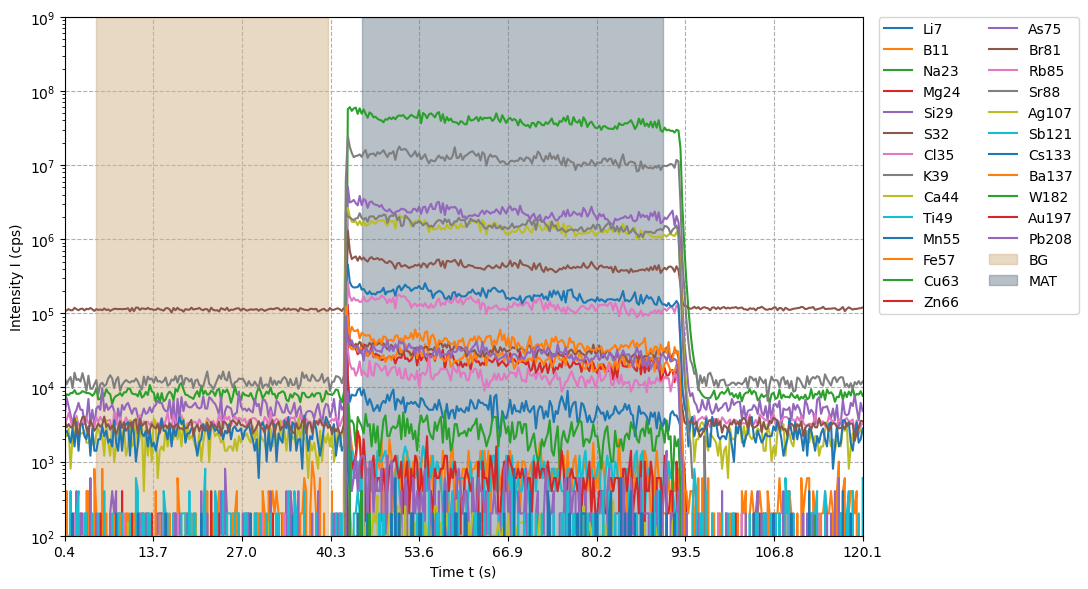

In [29]:
fname = "demo_fi13.csv"
file_path = demo_dir/fname
df = dri.read_input_data(file_path)
df_ready = dri.prepare_for_reduction(df)
list_isotopes = list(df_ready.keys())[1:]
print(list_isotopes)

if "BG" in files_srm_setup[fname]:
    intervals_bg = {"BG": files_srm_setup[fname]["BG"]}
else:
    intervals_bg = {"BG": [5, 40]}

if "MAT" in files_srm_setup[fname]:
    intervals_mat = {"MAT": [45, 90]}
else:
    intervals_mat = {"MAT": [45, 90]}

for key, interval in intervals_bg.items():
    if fname not in files_srm_setup:
        files_srm_setup[fname] = {}
    files_srm_setup[fname][key] = interval
    
for key, interval in intervals_mat.items():
    files_srm_setup[fname][key] = interval

plot_file(df=df_ready, intervals_bg=intervals_bg, intervals_mat=intervals_mat)


#### Data reduction

Calculation of
* background intensity
* sample intensity
* background-corrected sample intensity
* relative/normalized sensitivity

In [31]:
for fname, setup_info in files_srm_setup.items():
    file_path = demo_dir/fname
    df = dri.read_input_data(file_path)
    df_ready = dri.prepare_for_reduction(df)

    t_0 = setup_info["BG"][0]
    t_1 = setup_info["BG"][1]
    t_4 = setup_info["MAT"][0]
    t_5 = setup_info["MAT"][1]
    idx_0 = dri.find_index_for_time(df_ready=df_ready, time_value=t_0)
    idx_1 = dri.find_index_for_time(df_ready=df_ready, time_value=t_1)
    idx_4 = dri.find_index_for_time(df_ready=df_ready, time_value=t_4)
    idx_5 = dri.find_index_for_time(df_ready=df_ready, time_value=t_5)

    data_bg1 = dri.reduce_intervals(df_ready=df_ready, intervals=[(idx_0, idx_1)])
    data_sig = dri.reduce_intervals(df_ready=df_ready, intervals=[(idx_4, idx_5)])
    df_srm_intensities = dri.subtract_background(signal=data_sig["mean"], background=data_bg1["mean"])
    i_ratios = dri.compute_intensity_ratios(intensities=df_srm_intensities, reference_isotope=ref_isotope)

    isotope_to_element = build_isotope_to_element_mapping(i_ratios.index)
    drs = DRS(isotope_to_element)
    srmname = setup_info["SRM"]
    df_sens = drs.calculate_relative_sensitivity(
        intensity_ratios=i_ratios, concentration_ratios=df_srm_i_ratios[srmname])
    if "NIST" in srmname:
        srm_sensitivities_nist610[fname] = df_sens
    else:
        srm_sensitivities_sca17[fname] = df_sens
    srm_intensities[fname] = df_srm_intensities


    print("Filename:\t",fname)
    print("SRM:\t\t", setup_info["SRM"], "\n")
    try:
        print(srm_sensitivities_nist610[fname], "\n")
    except:
        pass
    try:
        print(srm_sensitivities_sca17[fname], "\n")
    except:
        pass

df_srm_intensities = pd.concat(srm_intensities.values(), axis=1)
df_srm_intensities = df_srm_intensities.mean(axis=1)


Filename:	 demo_fi01.csv
SRM:		 NIST_610_GeoReM.csv 

Li7     0.32765
B11     0.09572
Na23    1.00000
Mg24    0.58988
Si29    0.01431
S32     0.16423
Cl35    0.01713
K39     1.48982
Ca44    0.04482
Ti49    0.09859
Mn55    1.79615
Fe57    0.04371
Cu63    0.80497
Zn66    0.29702
As75    0.36990
Br81    0.03335
Rb85    2.62487
Sr88    3.22983
Ag107   1.25360
Sb121   1.17831
Cs133   4.44527
Ba137   0.50414
W182    0.77537
Au197   0.97366
Pb208   2.01152
Name: RSF, dtype: float64 

Filename:	 demo_fi02.csv
SRM:		 NIST_610_GeoReM.csv 

Li7     0.32956
B11     0.09708
Na23    1.00000
Mg24    0.58969
Si29    0.01428
S32     0.16884
Cl35    0.01843
K39     1.48482
Ca44    0.04487
Ti49    0.09882
Mn55    1.79224
Fe57    0.04349
Cu63    0.77389
Zn66    0.29850
As75    0.37230
Br81    0.03130
Rb85    2.62421
Sr88    3.24726
Ag107   1.26288
Sb121   1.19382
Cs133   4.51875
Ba137   0.50809
W182    0.78644
Au197   1.05459
Pb208   2.04136
Name: RSF, dtype: float64 

Filename:	 demo_fi03.csv
SRM:		 Scap

#### Import sample data (from LA-ICP-MS experiments)

#### demo_fi05

['Li7', 'B11', 'Na23', 'Mg24', 'Si29', 'S32', 'Cl35', 'K39', 'Ca44', 'Ti49', 'Mn55', 'Fe57', 'Cu63', 'Zn66', 'As75', 'Br81', 'Rb85', 'Sr88', 'Ag107', 'Sb121', 'Cs133', 'Ba137', 'W182', 'Au197', 'Pb208']


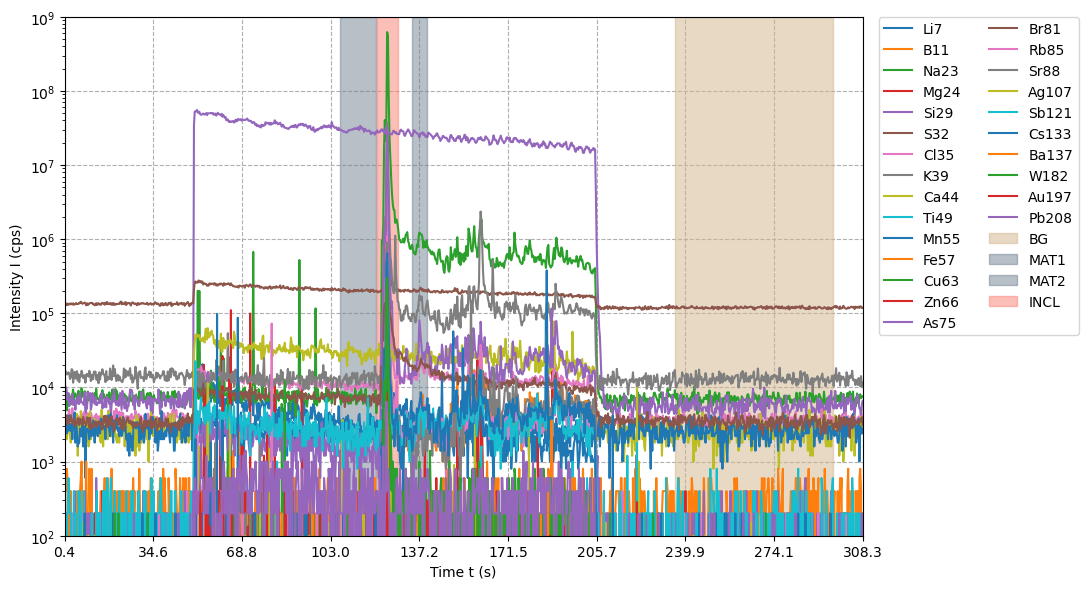

In [79]:
fname = "demo_fi05.csv"
file_path = demo_dir/fname
df = dri.read_input_data(file_path)
df_ready = dri.prepare_for_reduction(df)
list_isotopes = list(df_ready.keys())[1:]
print(list_isotopes)

if "BG" in files_smpl_setup[fname]:
    intervals_bg = {"BG": files_smpl_setup[fname]["BG"]}
else:
    intervals_bg = {"BG": [5, 40]}

if "MAT1" in files_smpl_setup[fname]:
    intervals_mat = {"MAT1": files_smpl_setup[fname]["MAT1"]}
else:
    intervals_mat = {"MAT1": [100, 120]}

if "MAT2" in files_smpl_setup[fname]:
    intervals_mat["MAT2"] = files_smpl_setup[fname]["MAT2"]
else:
    intervals_mat["MAT2"] = [130, 150]

if "INCL" in files_smpl_setup[fname]:
    intervals_incl = {"INCL": files_smpl_setup[fname]["INCL"]}
else:
    intervals_incl = {"INCL": [121, 129]}

for key, interval in intervals_bg.items():
    if fname not in files_smpl_setup:
        files_smpl_setup[fname] = {}
    files_smpl_setup[fname][key] = interval
    
for key, interval in intervals_mat.items():
    files_smpl_setup[fname][key] = interval

for key, interval in intervals_incl.items():
    files_smpl_setup[fname][key] = interval

plot_file(df=df_ready, intervals_bg=intervals_bg, intervals_mat=intervals_mat, intervals_incl=intervals_incl)


#### demo_fi06

['Li7', 'B11', 'Na23', 'Mg24', 'Si29', 'S32', 'Cl35', 'K39', 'Ca44', 'Ti49', 'Mn55', 'Fe57', 'Cu63', 'Zn66', 'As75', 'Br81', 'Rb85', 'Sr88', 'Ag107', 'Sb121', 'Cs133', 'Ba137', 'W182', 'Au197', 'Pb208']


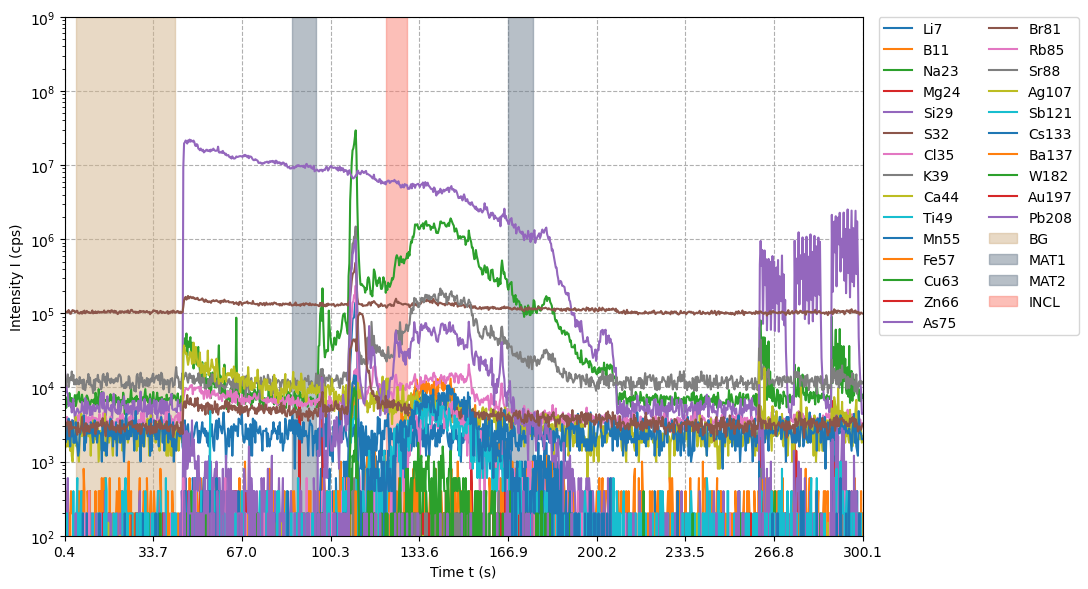

In [81]:
fname = "demo_fi06.csv"
file_path = demo_dir/fname
df = dri.read_input_data(file_path)
df_ready = dri.prepare_for_reduction(df)
list_isotopes = list(df_ready.keys())[1:]
print(list_isotopes)

if "BG" in files_smpl_setup[fname]:
    intervals_bg = {"BG": files_smpl_setup[fname]["BG"]}
else:
    intervals_bg = {"BG": [5, 40]}

if "MAT1" in files_smpl_setup[fname]:
    intervals_mat = {"MAT1": files_smpl_setup[fname]["MAT1"]}
else:
    intervals_mat = {"MAT1": [100, 120]}

if "MAT2" in files_smpl_setup[fname]:
    intervals_mat["MAT2"] = files_smpl_setup[fname]["MAT2"]
else:
    intervals_mat["MAT2"] = [130, 150]

if "INCL" in files_smpl_setup[fname]:
    intervals_incl = {"INCL": files_smpl_setup[fname]["INCL"]}
else:
    intervals_incl = {"INCL": [121, 129]}

for key, interval in intervals_bg.items():
    if fname not in files_smpl_setup:
        files_smpl_setup[fname] = {}
    files_smpl_setup[fname][key] = interval
    
for key, interval in intervals_mat.items():
    files_smpl_setup[fname][key] = interval

for key, interval in intervals_incl.items():
    files_smpl_setup[fname][key] = interval

plot_file(df=df_ready, intervals_bg=intervals_bg, intervals_mat=intervals_mat, intervals_incl=intervals_incl)


#### Data reduction

Calculation of
* background intensity
* sample intensity
* background-corrected matrix intensity
* background- and matrix-corrected inclusion intensity
* relative/normalized drift sensitivity
* mixed concentration ratio
* mass fraction
* matrix concentration
* mixed concentration
* inclusion concentration

In [38]:
results_smpl = {}
for fname, setup_info in files_smpl_setup.items():
    print("Current file:", fname)
    reference_concentration_incl = concentration_incl_is[fname]
    reference_concentration_incl_2 = concentration_incl_is2[fname]
    file_path = demo_dir/fname
    df = dri.read_input_data(file_path)
    df_ready = dri.prepare_for_reduction(df)
    time_delta = time_deltas[fname]["time_delta"]
    df_rsf_drift_nist610 = drs.calculate_sensitivity_drift(
        sensitivities_dict=srm_sensitivities_nist610, time_info=time_deltas)
    rsf_pred_nist610 = drs.predict_sensitivities(df_drift=df_rsf_drift_nist610, t_probe=time_delta)
    df_rsf_drift_sca17 = drs.calculate_sensitivity_drift(
        sensitivities_dict=srm_sensitivities_sca17, time_info=time_deltas)
    rsf_pred_sca17 = drs.predict_sensitivities(df_drift=df_rsf_drift_sca17, t_probe=time_delta)

    cols_replace = ["Cl35", "Br81"]
    df_sensitivity_drift = rsf_pred_nist610.copy()
    df_sensitivity_drift[cols_replace] = rsf_pred_sca17[cols_replace]

    t_0 = setup_info["BG"][0]
    t_1 = setup_info["BG"][1]
    t_2 = setup_info["MAT1"][0]
    t_3 = setup_info["MAT1"][1]
    t_4 = setup_info["MAT2"][0]
    t_5 = setup_info["MAT2"][1]
    t_6 = setup_info["INCL"][0]
    t_7 = setup_info["INCL"][1]
    idx_0 = dri.find_index_for_time(df_ready=df_ready, time_value=t_0)
    idx_1 = dri.find_index_for_time(df_ready=df_ready, time_value=t_1)
    idx_2 = dri.find_index_for_time(df_ready=df_ready, time_value=t_2)
    idx_3 = dri.find_index_for_time(df_ready=df_ready, time_value=t_3)
    idx_4 = dri.find_index_for_time(df_ready=df_ready, time_value=t_4)
    idx_5 = dri.find_index_for_time(df_ready=df_ready, time_value=t_5)
    idx_6 = dri.find_index_for_time(df_ready=df_ready, time_value=t_6)
    idx_7 = dri.find_index_for_time(df_ready=df_ready, time_value=t_7)

    data_bg1 = dri.reduce_intervals(df_ready=df_ready, intervals=[(idx_0, idx_1)])
    data_sig = dri.reduce_intervals(df_ready=df_ready, intervals=[(idx_2, idx_3), (idx_4, idx_5)])
    data_incl = dri.reduce_intervals(df_ready=df_ready, intervals=[(idx_6, idx_7)])

    # matrix quantification
    df_intensities_mat = dri.subtract_background(signal=data_sig["mean"], background=data_bg1["mean"])
    i_ratios = dri.compute_intensity_ratios(intensities=df_intensities_mat, reference_isotope=ref_isotope_matrix)
    df_concentrations_mat = SA(reference_isotope=ref_isotope_matrix).compute_concentrations(
        intensity_ratios=i_ratios, sensitivity_values=df_sensitivity_drift/df_sensitivity_drift[ref_isotope_matrix],
        reference_concentration=reference_concentration_mat)

    df_concentrations_mat = df_concentrations_mat.clip(lower=0.0)

    # inclusion quantification
    df_intensities_mix = dri.subtract_background(signal=data_incl["mean"], background=data_bg1["mean"])

    a = SA(reference_isotope=ref_isotope,
           reference_second_isotope=ref_isotope_2).calculate_mixed_concentration_ratio(
        intensities_mix=df_intensities_mix, sensitivity=df_sensitivity_drift)
    x = SA(reference_isotope=ref_isotope,
           reference_second_isotope=ref_isotope_2).calculate_mass_fraction(
        concentrations_mat=df_concentrations_mat, concentrations_incl={
            ref_isotope_2: reference_concentration_incl_2, ref_isotope: reference_concentration_incl},
        mixed_ratio=a)

    concentration_mix_is = (1 - x)*df_concentrations_mat[ref_isotope] + x*reference_concentration_incl
    i_mix_ratios = dri.compute_intensity_ratios(
        intensities=df_intensities_mix, reference_isotope=ref_isotope)
    df_concentrations_mix = SA(reference_isotope=ref_isotope).compute_concentrations(
        intensity_ratios=i_mix_ratios, sensitivity_values=df_sensitivity_drift,
        reference_concentration=concentration_mix_is)
    df_concentrations_incl_x = SA(reference_isotope=ref_isotope).calculate_inclusion_concentration_using_x(
        concentratios_mix=df_concentrations_mix, concentratios_host=df_concentrations_mat, mass_fraction=x)
    #df_intensities_incl_x = dri.calculate_inclusion_intensity_using_x(
    #    intensities_mix=df_intensities_mix, intensities_mat=df_intensities_mat, mass_fraction=x,
    #    concentrations_mat=df_concentrations_mat, concentration_mix=df_concentrations_mix,
    #    sensitivities=df_sensitivity_drift, reference_concentration_incl=reference_concentration_incl,
    #    reference_isotope=ref_isotope)
    #i_incl_ratios = dri.compute_intensity_ratios(intensities=df_intensities_incl_x, reference_isotope=ref_isotope)
    #df_concentrations_incl_alt = SA(reference_isotope=ref_isotope).compute_concentrations(
    #    intensity_ratios=i_incl_ratios, sensitivity_values=df_sensitivity_drift,
    #    reference_concentration=reference_concentration_incl)

    df_concentrations_incl_x = df_concentrations_incl_x.clip(lower=0.0)
    #df_concentrations_incl_alt = df_concentrations_incl_alt.clip(lower=0.0)
    df_concentrations_incl_x = df_concentrations_incl_x.mask(df_concentrations_incl_x > 1000000, 0.0)
    #df_concentrations_incl_alt = df_concentrations_incl_alt.mask(df_concentrations_incl_alt > 1000000, 0.0)
    df_concentrations_mix = df_concentrations_mix.clip(lower=0.0)
    #df_intensities_incl_x = df_intensities_incl_x.clip(lower=0.0)

    if fname in ["demo_fi05.csv", "demo_fi06.csv"]:
        print("Filename:", fname)
        print("\n-- results: matrix analysis\n")
        print(df_concentrations_mat)
        print(df_sensitivity_drift/df_sensitivity_drift[ref_isotope_matrix])
        print("\n-- results: inclusion analysis")
        print("a", round(a, 5), "x", round(x, 5), "\n")
        print(df_concentrations_incl_x)
        print(df_concentrations_mix)
        print(df_sensitivity_drift)
        #print(df_intensities_incl_x)
        #print(df_concentrations_incl_alt)
        #print(df_concentrations_incl_alt - df_concentrations_incl_x)
        

Current file: demo_fi05.csv
Filename: demo_fi05.csv

-- results: matrix analysis

Li7          2.27579
B11          2.78070
Na23        59.61920
Mg24         0.00363
Si29    467436.71250
S32        109.99281
Cl35       333.74706
K39          4.54620
Ca44       129.34639
Ti49         0.04401
Mn55         0.00000
Fe57         0.00000
Cu63         0.01434
Zn66         0.07146
As75         5.64638
Br81        18.89194
Rb85         0.08947
Sr88         0.03773
Ag107        0.01301
Sb121        0.47755
Cs133        0.06378
Ba137        0.00390
W182         0.02318
Au197        0.00232
Pb208        0.04172
Name: Concentration, dtype: float64
isotope
Li7      22.23649
B11       6.64007
Na23     69.98115
Mg24     41.07965
Si29      1.00000
S32      12.52290
Cl35      0.44525
K39     107.18719
Ca44      3.23121
Ti49      7.14513
Mn55    129.61011
Fe57      3.05024
Cu63     56.56686
Zn66     21.76131
As75     27.54090
Br81      6.22262
Rb85    195.07699
Sr88    240.50294
Ag107    92.48627
Sb121  

### Appendix

#### Show the whole dataset, including all intervals and along the whole x-range

['Li7', 'B11', 'Na23', 'Mg24', 'Si29', 'S32', 'Cl35', 'K39', 'Ca44', 'Ti49', 'Mn55', 'Fe57', 'Cu63', 'Zn66', 'As75', 'Br81', 'Rb85', 'Sr88', 'Ag107', 'Sb121', 'Cs133', 'Ba137', 'W182', 'Au197', 'Pb208']


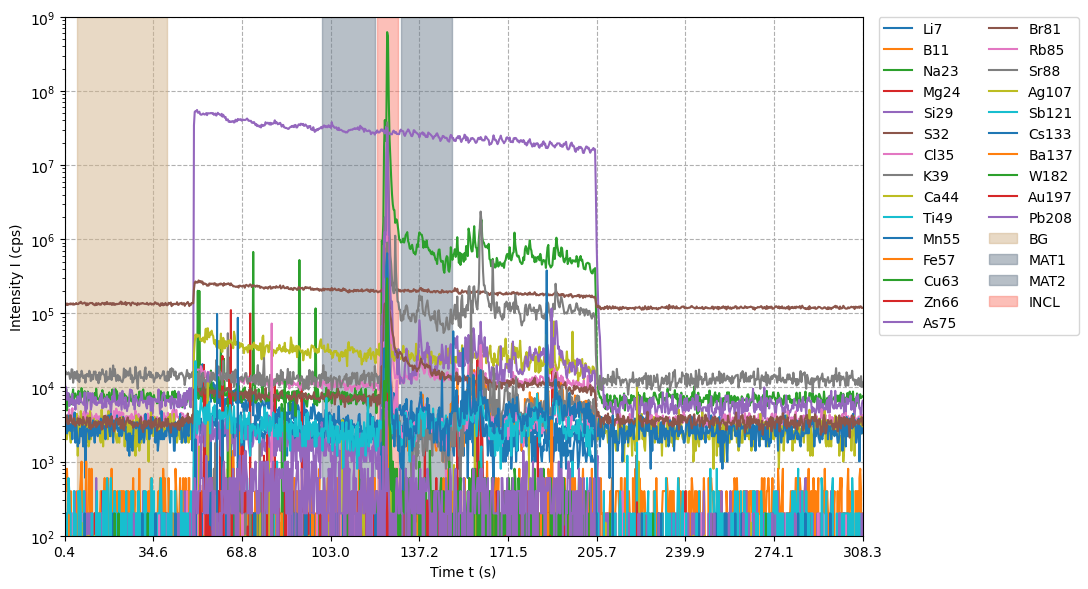

In [40]:
fname = "demo_fi05.csv"
file_path = demo_dir/fname
df = dri.read_input_data(file_path)
df_ready = dri.prepare_for_reduction(df)
list_isotopes = list(df_ready.keys())[1:]
print(list_isotopes)

intervals_bg = {"BG": [5, 40]}
intervals_mat = {"MAT1": [100, 120], "MAT2": [130, 150]}
intervals_incl = {"INCL": [121, 129]}

plot_file(df=df_ready, intervals_bg=intervals_bg, intervals_mat=intervals_mat, intervals_incl=intervals_incl)


#### Show the only a user-defined isotope, including all intervals but only along a limited x-range

['Li7', 'B11', 'Na23', 'Mg24', 'Si29', 'S32', 'Cl35', 'K39', 'Ca44', 'Ti49', 'Mn55', 'Fe57', 'Cu63', 'Zn66', 'As75', 'Br81', 'Rb85', 'Sr88', 'Ag107', 'Sb121', 'Cs133', 'Ba137', 'W182', 'Au197', 'Pb208']


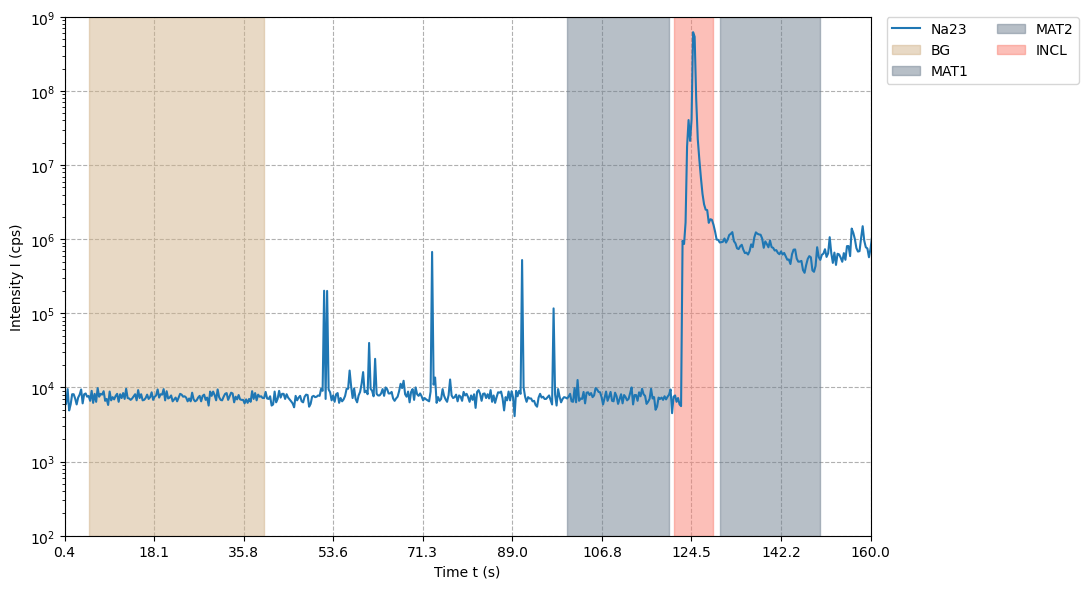

In [42]:
fname = "demo_fi05.csv"
file_path = demo_dir/fname
df = dri.read_input_data(file_path)
df_ready = dri.prepare_for_reduction(df)
list_isotopes = list(df_ready.keys())[1:]
print(list_isotopes)

intervals_bg = {"BG": [5, 40]}
intervals_mat = {"MAT1": [100, 120], "MAT2": [130, 150]}
intervals_incl = {"INCL": [121, 129]}

plot_file(df=df_ready, intervals_bg=intervals_bg, intervals_mat=intervals_mat, intervals_incl=intervals_incl, xlimits=[0, 160], focus="Na23")
